In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [43]:
df = pd.read_excel(r"H:\Python\3Etapa\Aula7GráficoPizza\Tabela_13_Meio_de_transporte.xlsx")

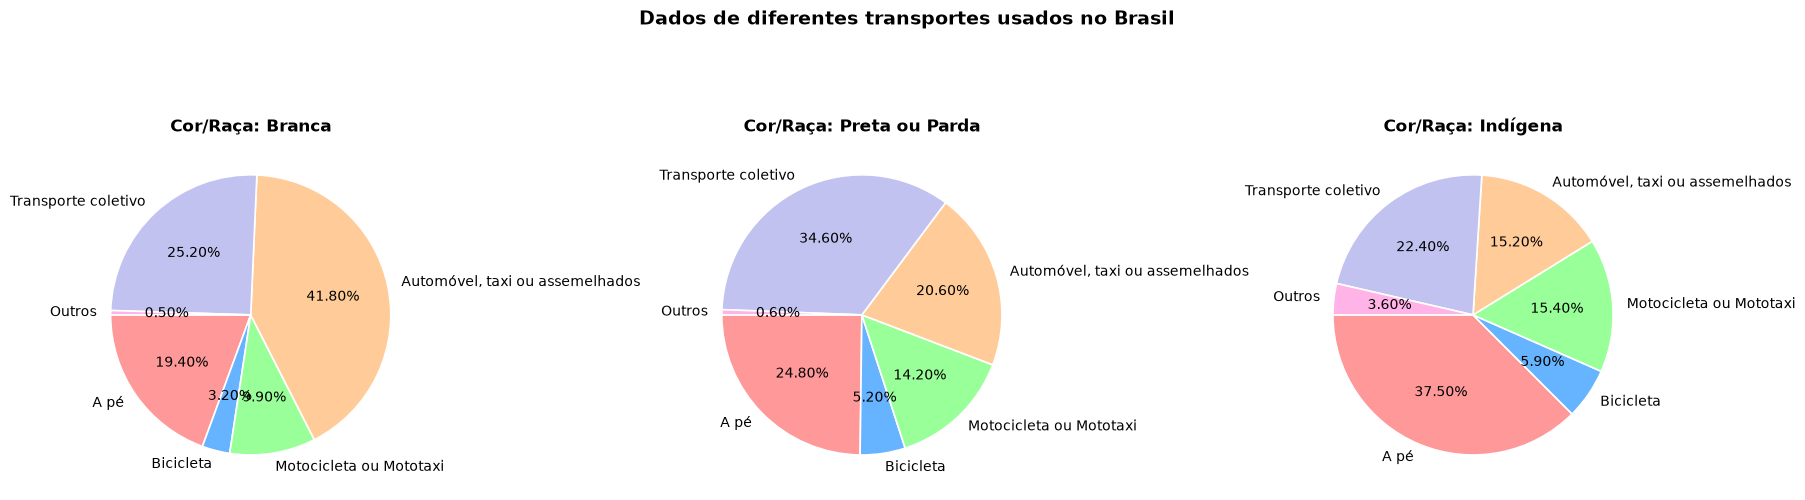

In [44]:
caminho_ficheiro = 'Tabela_13_Meio_de_transporte.xlsx'
df = pd.read_excel(
  caminho_ficheiro, sheet_name=1, skiprows=1
)

df.columns = ["Meio de Transporte", "Branca", "Preta ou Parda", "Indígena"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
  axes[i].pie(
      df[col],
      labels=df['Meio de Transporte'],
      autopct='%1.2f%%', 
      startangle=180, 
      colors=cores,
      wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
  )
  axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Dados de diferentes transportes usados no Brasil',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()

In [45]:
df["diferença bp"] = df["Branca"]  - df["Preta ou Parda"]

In [46]:
df

,Meio de Transporte,Branca,Preta ou Parda,Indígena,diferença bp
0,A pé,19.4,24.8,37.5,-5.4
1,Bicicleta,3.2,5.2,5.9,-2.0
2,Motocicleta ou Mototaxi,9.9,14.2,15.4,-4.3
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2,21.2
4,Transporte coletivo,25.2,34.6,22.4,-9.4
5,Outros,0.5,0.6,3.6,-0.1


In [47]:
import pandas as pd
import numpy as np

df = pd.read_excel("Tabela_13_Meio_de_transporte.xlsx", sheet_name="BR GR UF MU", skiprows=2, header=None)

colunas = ['Local', 
           'Branca_A pé', 'Branca_Bicicleta', 'Branca_Motocicleta', 'Branca_Carro', 'Branca_Coletivo', 'Branca_Outros',
           'PretaParda_A pé', 'PretaParda_Bicicleta', 'PretaParda_Motocicleta', 'PretaParda_Carro', 'PretaParda_Coletivo', 'PretaParda_Outros',
           'Indigena_A pé', 'Indigena_Bicicleta', 'Indigena_Motocicleta', 'Indigena_Carro', 'Indigena_Coletivo', 'Indigena_Outros']
df = df.iloc[:, :19]
df.columns = colunas
df['Local'] = df['Local'].astype(str).str.strip()

df_longo = df.melt(
    id_vars=['Local'],
    value_vars=colunas[1:],
    var_name="Categoria",
    value_name="Percentual"
)

df_longo['Percentual'] = pd.to_numeric(df_longo['Percentual'].replace(['-', ' ', '.', 'nan'], np.nan), errors='coerce').fillna(0)
df_longo[['Raca', 'Transporte']] = df_longo['Categoria'].str.split('_', expand=True)

df_geral = df_longo.groupby(['Local', 'Transporte'])['Percentual'].mean().reset_index()

estados = ['Rondônia', 'Acre', 'Amazonas', 'Roraima', 'Pará', 'Amapá', 'Tocantins', 'Maranhão', 'Piauí', 'Ceará', 'Rio Grande do Norte', 'Paraíba', 'Pernambuco', 'Alagoas', 'Sergipe', 'Bahia', 'Minas Gerais', 'Espírito Santo', 'Rio de Janeiro', 'São Paulo', 'Paraná', 'Santa Catarina', 'Rio Grande do Sul', 'Mato Grosso do Sul', 'Mato Grosso', 'Goiás', 'Distrito Federal']
excluir = estados + ['Brasil', 'Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-oeste', 'nan']

df_est = df_geral[df_geral['Local'].isin(estados)]
df_cid = df_geral[~df_geral['Local'].isin(excluir)]

In [48]:
# Qual estado tem mais mulheres, em geral, utilizando o transporte coletivo e qual tem menos mulheres utilizando?

coletivo = df_est[df_est['Transporte'] == 'Coletivo']
print("Mais Coletivo (Estado):", coletivo.loc[coletivo['Percentual'].idxmax(), 'Local'])
print("Menos Coletivo (Estado):", coletivo.loc[coletivo['Percentual'].idxmin(), 'Local'])

Mais Coletivo (Estado): Rio de Janeiro
Menos Coletivo (Estado): Rondônia


In [49]:
# Qual cidade do Brasil te mais mulheres andando de bicicleta?

bike = df_cid[df_cid['Transporte'] == 'Bicicleta']
print("Mais Bicicleta (Cidade):", bike.loc[bike['Percentual'].idxmax(), 'Local'])

Mais Bicicleta (Cidade): Lagoa Grande (MG)


In [50]:
# Qual cidade do Brasil te mais mulheres utilizando carro?

carro = df_cid[df_cid['Transporte'] == 'Carro']
print("Mais Carro (Cidade):", carro.loc[carro['Percentual'].idxmax(), 'Local'])

Mais Carro (Cidade): Bom Jesus (SC)
